=======================================

In [22]:
import pandas as pd
import numpy as np

# Load your modified dataset
file_path = '../data/merged_dataset_2000_2019.csv'
data = pd.read_csv(file_path)

# Check for initial missing values
missing_values = data.isnull().sum()
print("Initial missing values in the dataset:")
print(missing_values)

Initial missing values in the dataset:
Period                                                                                                                                                        0
ParentLocation                                                                                                                                                0
Location                                                                                                                                                      0
Dim1                                                                                                                                                          0
HALE_Birth                                                                                                                                                    0
HALE_60                                                                                                                                                       0
i

In [23]:
# 1. Filter the data for the period 2000-2019
data_filtered = data[(data['Period'] >= 2000) & (data['Period'] <= 2019)].copy()

# 2. Drop columns with more than 60% missing values
threshold = 0.6 * len(data_filtered)
data_filtered_cleaned = data_filtered.dropna(thresh=threshold, axis=1).copy()

# Show missing values after filtering and dropping columns
missing_after_filter = data_filtered_cleaned.isnull().sum()
print("Missing values after filtering and dropping sparse columns:")
print(missing_after_filter)

Missing values after filtering and dropping sparse columns:
Period                                                                                                                                                        0
ParentLocation                                                                                                                                                0
Location                                                                                                                                                      0
Dim1                                                                                                                                                          0
HALE_Birth                                                                                                                                                    0
HALE_60                                                                                                                                     

In [24]:
# 3. Backward fill for missing values ONLY in the year 2000
for country in data_filtered_cleaned['Location'].unique():
    country_mask = data_filtered_cleaned['Location'] == country
    country_data = data_filtered_cleaned[country_mask]

    mask_2000 = (data_filtered_cleaned['Location'] == country) & (data_filtered_cleaned['Period'] == 2000)

    if not data_filtered_cleaned[mask_2000].empty:
        future_data = country_data[country_data['Period'] > 2000].sort_values('Period')
        if not future_data.empty:
            data_filtered_cleaned.loc[mask_2000] = data_filtered_cleaned.loc[mask_2000].fillna(future_data.iloc[0])

data_filtered_cleaned = data_filtered_cleaned.round(2)

print("Missing values after backward filling year 2000:")
print(data_filtered_cleaned.isnull().sum())

Missing values after backward filling year 2000:
Period                                                                                                                                                        0
ParentLocation                                                                                                                                                0
Location                                                                                                                                                      0
Dim1                                                                                                                                                          0
HALE_Birth                                                                                                                                                    0
HALE_60                                                                                                                                                

In [25]:
import pandas as pd
import numpy as np

# 1. Separate numeric columns and categorical columns
# This prevents the 'object dtype' warning
numeric_cols = data_filtered_cleaned.select_dtypes(include=[np.number]).columns
categorical_cols = data_filtered_cleaned.select_dtypes(exclude=[np.number]).columns

# 2. Apply interpolation ONLY on numeric columns, grouped by Location
# This ensures each country's gaps are filled based on its own trend
data_interpolated_numeric = data_filtered_cleaned.groupby('Location', group_keys=False)[numeric_cols].apply(
    lambda group: group.interpolate(method='linear')
)

# 3. Combine the numeric results back with the categorical columns
data_interpolated = pd.concat([data_filtered_cleaned[categorical_cols], data_interpolated_numeric], axis=1)

# 4. Final step: Round values and check for any remaining nulls
data_interpolated = data_interpolated.round(2)

print("Success! Missing values after fixed interpolation:")
print(data_interpolated.isnull().sum())

Success! Missing values after fixed interpolation:
ParentLocation                                                                                                                                                0
Location                                                                                                                                                      0
Dim1                                                                                                                                                          0
Period                                                                                                                                                        0
HALE_Birth                                                                                                                                                    0
HALE_60                                                                                                                                              

In [26]:
# 5. Global Mean Imputation for any remaining missing values
data_final = data_interpolated.fillna(data_interpolated.mean(numeric_only=True))
data_final = data_final.round(2)

print("Final check for missing values (Should be 0):")
print(data_final.isnull().sum())

Final check for missing values (Should be 0):
ParentLocation                                                                                                                                             0
Location                                                                                                                                                   0
Dim1                                                                                                                                                       0
Period                                                                                                                                                     0
HALE_Birth                                                                                                                                                 0
HALE_60                                                                                                                                                    0
infant morta

In [27]:
# 6. Save the final cleaned dataset
output_file = '../data/cleaned_merged_dataset.csv'
data_final.to_csv(output_file, index=False)

print(f"Data preprocessing complete! The cleaned dataset is saved as '{output_file}'.")

Data preprocessing complete! The cleaned dataset is saved as '../data/cleaned_merged_dataset.csv'.


_____________________________

In [28]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import numpy as np

# Load the cleaned dataset (result of the previous preprocessing step)
file_path = '../data/cleaned_merged_dataset.csv'
data = pd.read_csv(file_path)

# Quick check to ensure no missing values remain before normalization
print("Missing values check:")
print(data.isnull().sum().sum())

Missing values check:
0


In [29]:
# Z-score Standardization for features measured in years or rates
zscore_columns = [
    'HALE_Birth',
    'HALE_60',
    'infant mortality rate (between birth and 11 months per 1000 live births)',
    'Age-standardized suicide rates (per 100 000 population)',
    'Alcohol, total per capita (15+ years) consumption (in litres of pure alcohol) (SDG Indicator 3.5.2)',
    'Estimates of rate of homicides (per 100 000 population)',
    'Mean Total Cholesterol (crude estimate)',
    'PM2.5_Exposure',
    'Health_Expenditure_pct_GDP'
]

scaler_zscore = StandardScaler()
data[zscore_columns] = scaler_zscore.fit_transform(data[zscore_columns])

print("Z-score normalization complete.")

Z-score normalization complete.


In [30]:
# Min-Max Scaling for percentage-based columns
# Note: Tobacco column was removed because it had >60% missing values and was dropped during cleaning
percentage_columns = [
    'Prevalence of insufficient physical activity among adults aged 18+ years (age-standardized estimate) (%)',
    'Prevalence of obesity among adults, BMI ³ 30 (age-standardized estimate) (%)',
    'Prevalence of raised blood pressure among adults aged 30-79 years',
    'Probability of dying between the exact ages 30 and 70 years from cardiovascular diseases, cancer, diabetes, or chronic respiratory diseases (SDG 3.4.1)',
    'Undernourishment_Prevalence'
]

scaler_minmax = MinMaxScaler()
data[percentage_columns] = scaler_minmax.fit_transform(data[percentage_columns])

print("Min-Max scaling complete for existing columns.")

Min-Max scaling complete for existing columns.


In [31]:
# 1. Cyclical encoding for 'Period' (to help the model understand time loops)
data['Period_sin'] = np.sin(2 * np.pi * data['Period'] / data['Period'].max())
data['Period_cos'] = np.cos(2 * np.pi * data['Period'] / data['Period'].max())

# 2. Convert text columns (Country, Region, Gender) into numbers
# Using drop_first=True to avoid redundancy in the data
data_final = pd.get_dummies(data, columns=['ParentLocation', 'Location', 'Dim1'], drop_first=True)

print(f"Final dataset shape: {data_final.shape}")

Final dataset shape: (11100, 208)


In [32]:
# Saving the ready-to-use dataset
output_file = '../data/final_normalized_data_for_ML.csv'
data_final.to_csv(output_file, index=False)

print(f"Ready! Dataset saved as '{output_file}'. You can now start training your models.")

Ready! Dataset saved as '../data/final_normalized_data_for_ML.csv'. You can now start training your models.


--------------------

In [33]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [35]:
data = pd.read_csv('../data/cleaned_merged_dataset.csv')

In [36]:
zscore_columns = [
'HALE_Birth', 'HALE_60',
'infant mortality rate (between birth and 11 months per 1000 live births)',
'Age-standardized suicide rates (per 100 000 population)',
'Alcohol, total per capita (15+ years) consumption (in litres of pure alcohol) (SDG Indicator 3.5.2)',
'Estimates of rate of homicides (per 100 000 population)',
'Mean Total Cholesterol (crude estimate)',
'PM2.5_Exposure', 'Health_Expenditure_pct_GDP'
]

percentage_columns = [
'Prevalence of insufficient physical activity among adults aged 18+ years (age-standardized estimate) (%)',
'Prevalence of obesity among adults, BMI ³ 30 (age-standardized estimate) (%)',
'Prevalence of raised blood pressure among adults aged 30-79 years',
'Probability of dying between the exact ages 30 and 70 years from cardiovascular diseases, cancer, diabetes, or chronic respiratory diseases (SDG 3.4.1)',
'Undernourishment_Prevalence'
]

In [37]:
scaler_zscore = StandardScaler()
data[zscore_columns] = scaler_zscore.fit_transform(data[zscore_columns])

In [38]:
scaler_minmax = MinMaxScaler()
data[percentage_columns] = scaler_minmax.fit_transform(data[percentage_columns])

print("Normalization complete.")

Normalization complete.


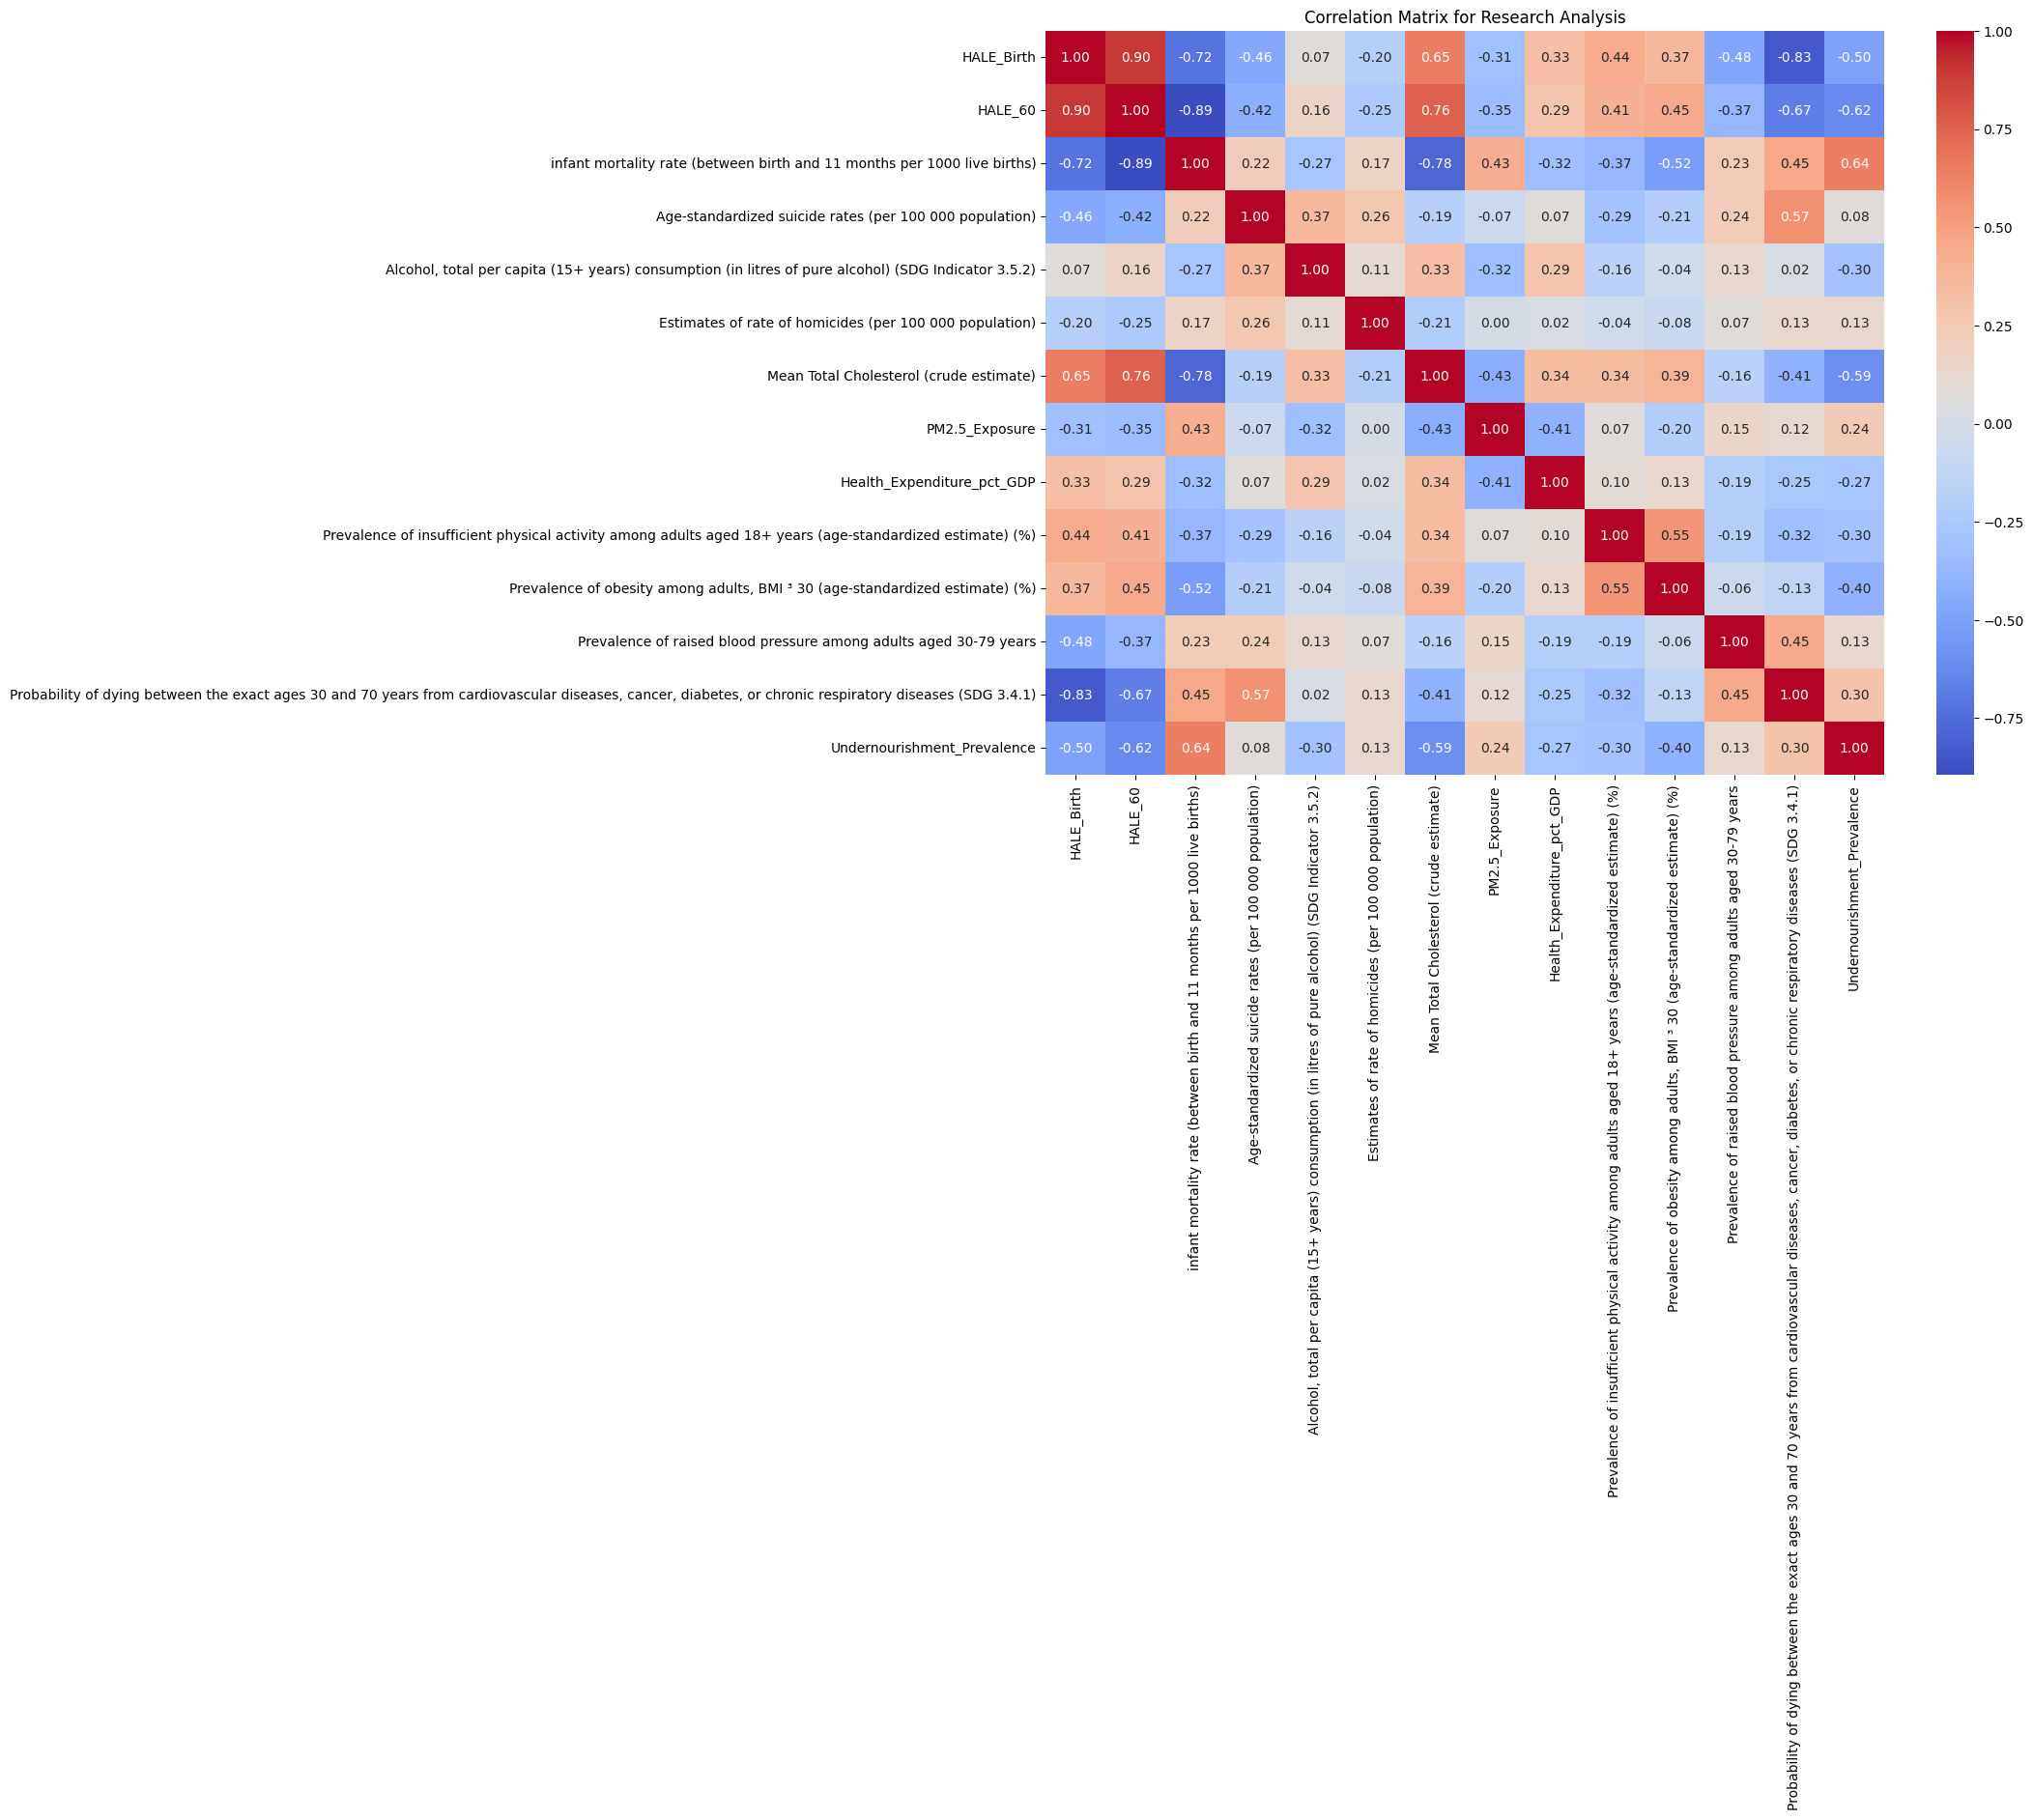

In [39]:
numerical_data = data[zscore_columns + percentage_columns]
plt.figure(figsize=(14, 10))
sns.heatmap(numerical_data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix for Research Analysis')
plt.show()

In [40]:
data['Period_sin'] = np.sin(2 * np.pi * data['Period'] / data['Period'].max())
data['Period_cos'] = np.cos(2 * np.pi * data['Period'] / data['Period'].max())

data_final = pd.get_dummies(data, columns=['ParentLocation', 'Location', 'Dim1'], drop_first=True)

In [41]:
output_name = '../data/final_normalized_data_for_ML.csv'
data_final.to_csv(output_name, index=False)
print("Ready! File saved as:", output_name)

Ready! File saved as: ../data/final_normalized_data_for_ML.csv


_________________________________

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

In [43]:
data = pd.read_csv('../data/cleaned_merged_dataset.csv')

print("Summary Statistics:")
print(data.describe())

Summary Statistics:
             Period    HALE_Birth       HALE_60  \
count  11100.000000  11100.000000  11100.000000   
mean    2009.500000     14.427315     60.916063   
std        5.766541      2.521464      7.551053   
min     2000.000000      7.200000     31.900000   
25%     2004.750000     12.500000     55.900000   
50%     2009.500000     14.300000     62.800000   
75%     2014.250000     16.400000     66.700000   
max     2019.000000     21.900000     75.000000   

       infant mortality rate (between birth and 11 months per 1000 live births)  \
count                                       11100.000000                          
mean                                           28.715324                          
std                                            26.370519                          
min                                             1.600000                          
25%                                             7.687500                          
50%                   

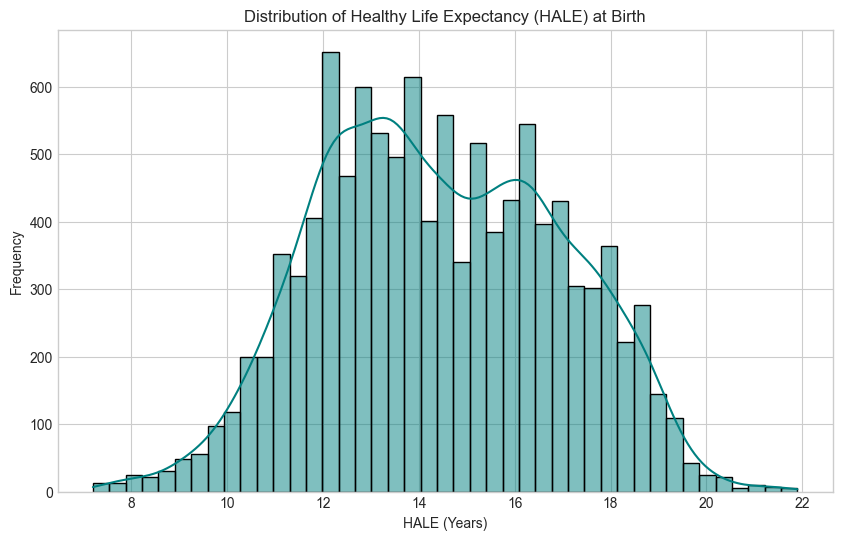

In [44]:
plt.figure(figsize=(10, 6))
sns.histplot(data['HALE_Birth'], kde=True, color='teal')
plt.title('Distribution of Healthy Life Expectancy (HALE) at Birth')
plt.xlabel('HALE (Years)')
plt.ylabel('Frequency')
plt.show()

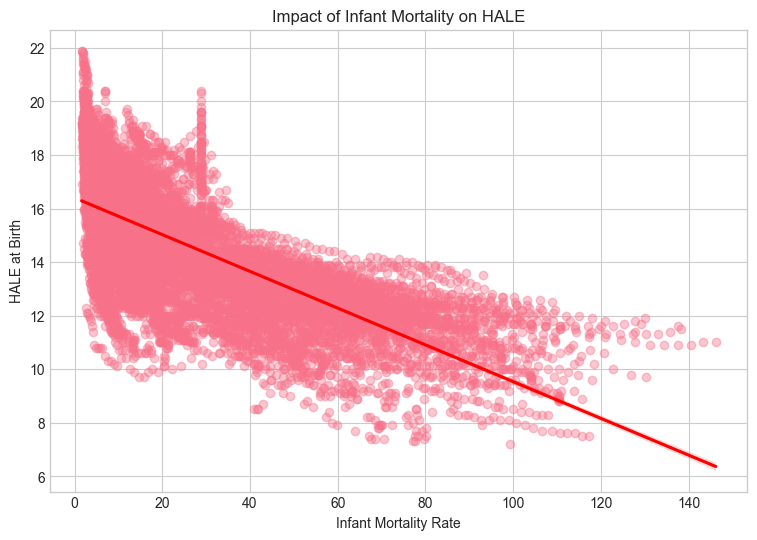

In [45]:
plt.figure(figsize=(9, 6))
sns.regplot(data=data, x='infant mortality rate (between birth and 11 months per 1000 live births)',
y='HALE_Birth', scatter_kws={'alpha':0.4}, line_kws={'color':'red'})
plt.title('Impact of Infant Mortality on HALE')
plt.xlabel('Infant Mortality Rate')
plt.ylabel('HALE at Birth')
plt.show()

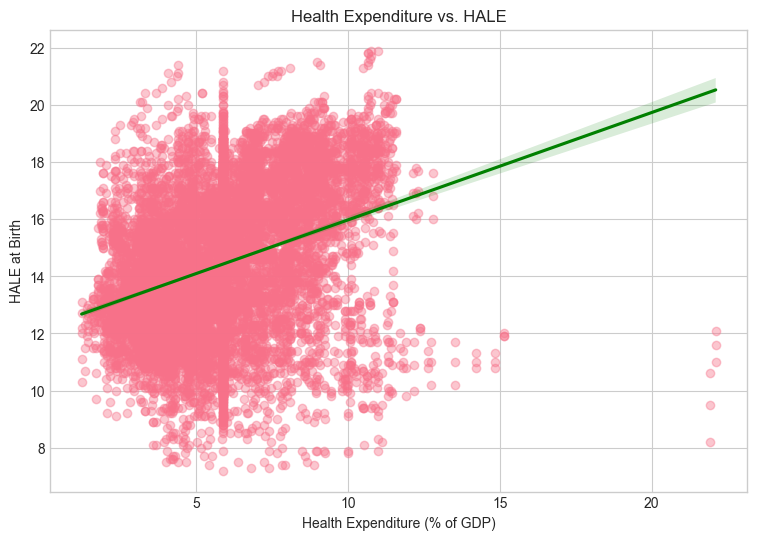

In [46]:
plt.figure(figsize=(9, 6))
sns.regplot(data=data, x='Health_Expenditure_pct_GDP', y='HALE_Birth',
scatter_kws={'alpha':0.4}, line_kws={'color':'green'})
plt.title('Health Expenditure vs. HALE')
plt.xlabel('Health Expenditure (% of GDP)')
plt.ylabel('HALE at Birth')
plt.show()

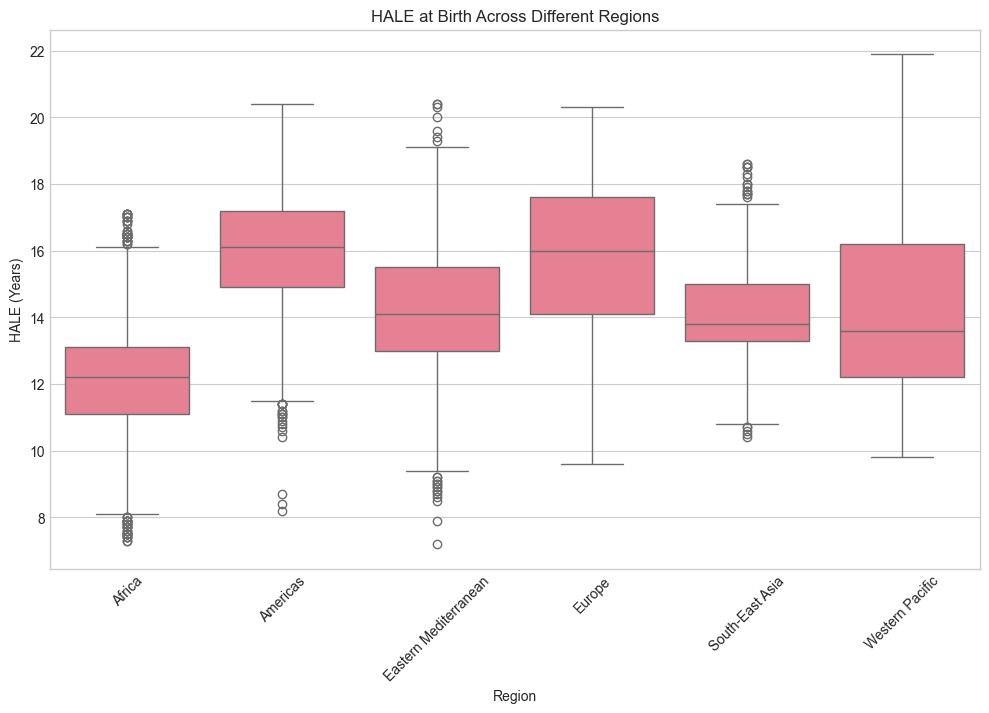

In [47]:
plt.figure(figsize=(12, 7))
sns.boxplot(data=data, x='ParentLocation', y='HALE_Birth')
plt.xticks(rotation=45)
plt.title('HALE at Birth Across Different Regions')
plt.xlabel('Region')
plt.ylabel('HALE (Years)')
plt.show()

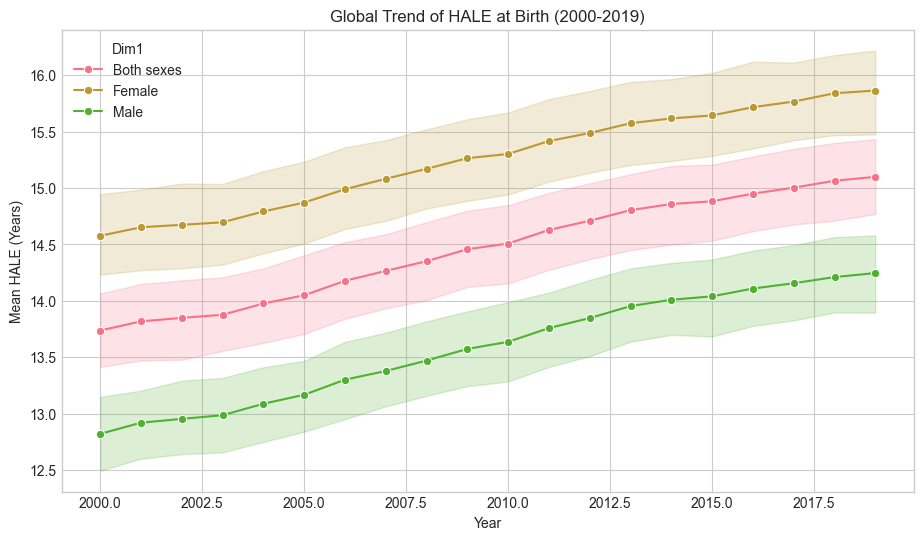

In [48]:
plt.figure(figsize=(11, 6))
sns.lineplot(data=data, x='Period', y='HALE_Birth', hue='Dim1', marker='o')
plt.title('Global Trend of HALE at Birth (2000-2019)')
plt.xlabel('Year')
plt.ylabel('Mean HALE (Years)')
plt.show()

____________________

In [49]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

In [50]:
data = pd.read_csv('../data/final_normalized_data_for_ML.csv')
X = data.drop(columns=['HALE_Birth'])
y = data['HALE_Birth']

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 8880 samples
Testing set size: 2220 samples


In [52]:
# Initialize models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results = {}

# Start the training loop
for name, model in models.items():
    # الأسطر التالية يجب أن تبدأ بمسافة (Tab) لأنها تابعة للـ for loop
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    # Calculate performance metrics
    mse = mean_squared_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    # Store results in the dictionary
    results[name] = {'MSE': mse, 'R2 Score': r2}
    print(f"{name} - Training Complete.")

Linear Regression - Training Complete.
Random Forest - Training Complete.
Gradient Boosting - Training Complete.


In [53]:
results_df = pd.DataFrame(results).T
print("\nModel Performance Comparison:")
print(results_df)

rf_model = models["Random Forest"]
importances = rf_model.feature_importances_
feature_names = X.columns


Model Performance Comparison:
                        MSE  R2 Score
Linear Regression  0.021341  0.979746
Random Forest      0.005599  0.994686
Gradient Boosting  0.028326  0.973117


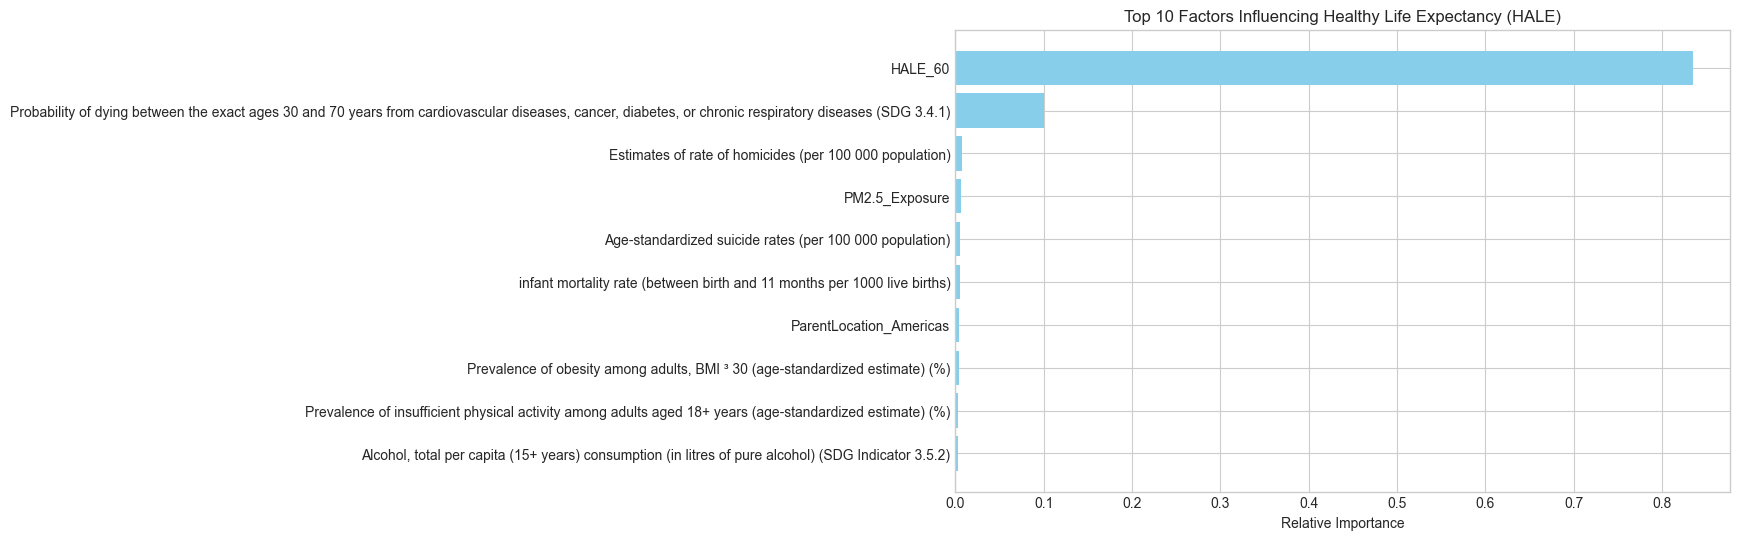

In [54]:
indices = np.argsort(importances)[-10:]

plt.figure(figsize=(10, 6))
plt.title('Top 10 Factors Influencing Healthy Life Expectancy (HALE)')
plt.barh(range(len(indices)), importances[indices], color='skyblue', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

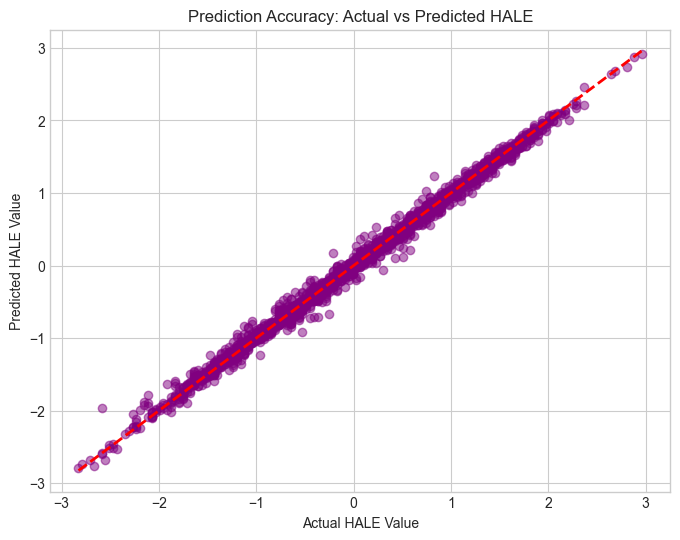

In [55]:
best_model = models["Random Forest"] # Assuming RF performs best
y_pred = best_model.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual HALE Value')
plt.ylabel('Predicted HALE Value')
plt.title('Prediction Accuracy: Actual vs Predicted HALE')
plt.show()